# xG × Fatigue — Does Shot Quality Change as Players Tire?

Two questions:

1. **Descriptive trend**: Does a shooter's base-model xG drift over their cumulative
   ice time? (LOWESS on per-shot xG vs. cumulative ice time before the shift.)

2. **Augmented logistic regression**: Does adding fatigue/stamina predictors from
   `shift_df` improve over the base xG model, and which predictors are significant?

**Join strategy**: for each shot, find the shooter's active shift in `shift_df`
(same game / period / player, shift_start_s ≤ shot elapsed_s ≤ shift_end_s) and
pull in `cumulative_ice_min_before`, `rest_time_s`, `position`, and the stamina
metrics (`mean_accel_magnitude`, `dist_ft_per_min`, etc.).

Shots with no matching shift (goalie saves from bench, shot while changing, etc.)
are dropped — they're rare and uninterpretable for fatigue analysis.

In [15]:
import sys, warnings
sys.path.insert(0, str(__import__('pathlib').Path('.').resolve()))
sys.path.insert(0, str(__import__('pathlib').Path('..').resolve()))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import roc_auc_score, log_loss

from build_shift_df import build_shift_df, POS_COLORS
from utils import load_events
import xg_model as xgm

OUTPUT_DIR = __import__('pathlib').Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

events    = load_events('../data/events.parquet')
shift_df  = build_shift_df('../data')   # use cache if fresh

shift_df['is_first_int']       = shift_df['is_first_shift'].astype(int)
shift_df['rest_time_min']      = shift_df['rest_time_s'] / 60.0
shift_df['shift_duration_min'] = shift_df['shift_duration_s'] / 60.0

print(f'Events  : {len(events):,}')
print(f'shift_df: {len(shift_df):,} shifts')

Loading cached shift_df from /Users/joeharter/repos/bdc-2026/stamina_models/shift_df.parquet
Events  : 19,200
shift_df: 6,218 shifts


## Step 1 — Fit base xG model & score all shots

In [2]:
# Fit base logistic xG model (distance + angle + shot type)
xg_pipe = xgm.fit_xg_model(events, verbose=True)

# Score every unblocked shot
shots = xgm.score_shots(xg_pipe, events)
shots = shots.dropna(subset=['xg', 'X_Coordinate', 'Y_Coordinate']).copy()
shots['elapsed_in_period_s'] = shots['Elapsed_s'] - (shots['Period_int'] - 1) * 1200

# Base model AUC / log-loss reference
base_auc  = roc_auc_score(shots['is_goal'], shots['xg'])
base_ll   = log_loss(shots['is_goal'], shots['xg'])
base_null_ll = log_loss(shots['is_goal'], np.full(len(shots), shots['is_goal'].mean()))

print(f"\nBase xG model ({len(shots):,} shots)")
print(f"  AUC          : {base_auc:.4f}")
print(f"  Log-loss     : {base_ll:.4f}")
print(f"  Null log-loss: {base_null_ll:.4f}")
print(f"  Goals        : {int(shots['is_goal'].sum())} / {len(shots)} ({shots['is_goal'].mean():.1%})")
print(f"  Mean xG      : {shots['xg'].mean():.4f}")

xG model trained on 1,190 unblocked shots
  Goals      : 58  (4.9% conversion)
  Mean xG    : 0.0487
  Shot types : {'Wristshot': 517, 'Snapshot': 450, 'Slapshot': 116, 'Deflection': 64, 'Fan': 32, 'Wrap Around': 6, 'Bat': 3, 'Poke': 2}
  Coef (dist, angle): [-1.39  -0.375]

Base xG model (1,190 shots)
  AUC          : 0.8280
  Log-loss     : 0.1598
  Null log-loss: 0.1948
  Goals        : 58 / 1190 (4.9%)
  Mean xG      : 0.0487


## Step 2 — Join shots to shooter's active shift

For each shot, find the matching row in `shift_df` where the shooter was on ice
(same game / period / player, `shift_start_s ≤ elapsed_in_period_s ≤ shift_end_s`).
This attaches cumulative ice time, rest time, position, and stamina metrics.

In [17]:
# shots needs a 'Game' column in the same format as shift_df
shots['Player_Id'] = shots['Player_Id'].astype(str)

shift_lookup = shift_df[[
    'Game', 'Period_int', 'Player_Id', 'Team',
    'shift_start_s', 'shift_end_s', 'shift_duration_s', 'shift_duration_min',
    'rest_time_s', 'rest_time_min', 'is_first_shift', 'is_first_int',
    'cumulative_ice_min_before',
    'position',
    'dist_ft_per_min', 'speed_mean',
    'mean_accel_magnitude', 'accelerations_per_min', 'acceleration_events_per_min',
    'score_diff',
]].copy()

# Merge on game / period / player, then filter to only rows where shot falls in the shift window
merged = shots.merge(
    shift_lookup,
    on=['Game', 'Period_int', 'Player_Id'],
    how='inner',
    suffixes=('_shot', '_shift'),
)

# Keep only the shift that was active at the time of the shot
in_shift = (
    (merged['elapsed_in_period_s'] >= merged['shift_start_s']) &
    (merged['elapsed_in_period_s'] <= merged['shift_end_s'] + 2)   # +2 s grace: clock rounding
)
shot_shifts = merged[in_shift].copy()

# If multiple shifts still match (rare overlap), keep the closest start
shot_shifts['_start_gap'] = shot_shifts['elapsed_in_period_s'] - shot_shifts['shift_start_s']
shot_shifts = (
    shot_shifts.sort_values('_start_gap')
    .groupby(['Game', 'Period_int', 'Elapsed_s', 'Player_Id'], as_index=False)
    .first()
    .drop(columns=['_start_gap'])
)

# Unmatched shots (player not in shift_df window — e.g. OT, goalie, line change edge)
n_total   = len(shots)
n_matched = len(shot_shifts)
print(f"Shots total        : {n_total:,}")
print(f"Shots with shift   : {n_matched:,}  ({100*n_matched/n_total:.1f}%)")
print(f"Shots dropped      : {n_total - n_matched:,}")
print(f"\nGoal rate (matched): {shot_shifts['is_goal'].mean():.3%}")
print(f"Mean xG  (matched) : {shot_shifts['xg'].mean():.4f}")

Shots total        : 1,190
Shots with shift   : 999  (83.9%)
Shots dropped      : 191

Goal rate (matched): 4.204%
Mean xG  (matched) : 0.0491


## Step 3 — Descriptive: Does xG drift with fatigue?

LOWESS of per-shot xG vs. the shooter's cumulative ice time before the shift,
split by position. A downward slope would suggest fatigued shooters take lower-quality shots.

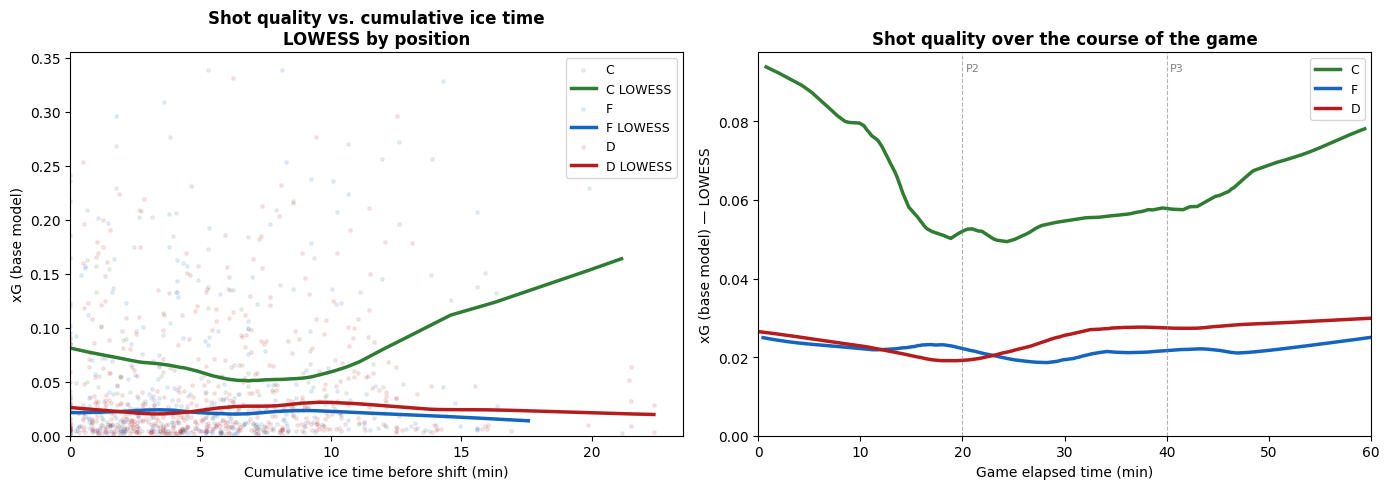

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: xG vs cumulative ice time ───────────────────────────────────────
ax = axes[0]
for pos, col in POS_COLORS.items():
    s = shot_shifts[shot_shifts['position'] == pos]
    ax.scatter(s['cumulative_ice_min_before'], s['xg'],
               alpha=0.10, s=6, color=col, label=pos, rasterized=True)
    if len(s) >= 30:
        lw_out = lowess(s['xg'].values, s['cumulative_ice_min_before'].values,
                        frac=0.5, return_sorted=True)
        ax.plot(lw_out[:, 0], lw_out[:, 1], color=col, lw=2.5, label=f'{pos} LOWESS')
ax.set_xlabel('Cumulative ice time before shift (min)')
ax.set_ylabel('xG (base model)')
ax.set_title('Shot quality vs. cumulative ice time\nLOWESS by position', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# ── Panel 2: xG vs elapsed game time ─────────────────────────────────────────
ax = axes[1]
shot_shifts['game_elapsed_min'] = (
    (shot_shifts['Period_int'] - 1) * 20 +
    shot_shifts['elapsed_in_period_s'] / 60.0
)
for pos, col in POS_COLORS.items():
    s = shot_shifts[shot_shifts['position'] == pos]
    if len(s) >= 30:
        lw_out = lowess(s['xg'].values, s['game_elapsed_min'].values,
                        frac=0.4, return_sorted=True)
        ax.plot(lw_out[:, 0], lw_out[:, 1], color=col, lw=2.5, label=pos)
# Period boundaries
for xv in [20, 40]:
    ax.axvline(xv, color='gray', lw=0.8, ls='--', alpha=0.6)
    ax.text(xv + 0.3, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 0.12,
            f'P{xv//20+1}', fontsize=8, color='gray')
ax.set_xlabel('Game elapsed time (min)')
ax.set_ylabel('xG (base model) — LOWESS')
ax.set_title('Shot quality over the course of the game', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 60)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_xg_vs_fatigue_lowess.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Augmented logistic regression

Add stamina predictors on top of the base xG shot features. If fatigue matters,
these coefficients will be significant and the model AUC will improve.

We use statsmodels logit (not sklearn) so we get proper p-values and a likelihood
ratio test (LRT) against the base xG-only specification.

In [ ]:

model_df = shot_shifts.dropna(subset=[
    'is_goal', 'xg', 'shot_dist_ft', 'shot_angle_deg', 'shot_type',
    'cumulative_ice_min_before', 'rest_time_min', 'position',
    'score_diff', 'mean_accel_magnitude', 'shift_duration_min',
]).copy()

print(f"Model rows: {len(model_df):,}")

# ── Base model (shot features only) ──────────────────────────────────────────
base_formula = 'is_goal ~ shot_dist_ft + shot_angle_deg + C(shot_type)'
base_formula = 'is_goal ~ shot_dist_ft + shot_angle_deg '
logit_base = smf.logit(base_formula, data=model_df).fit(disp=False, method='bfgs')

# ── Augmented model (+ fatigue predictors) ───────────────────────────────────
aug_formula = (
    # 'is_goal ~ shot_dist_ft + shot_angle_deg + C(shot_type) '
    'is_goal ~ shot_dist_ft + shot_angle_deg  '
    '+ cumulative_ice_min_before '
    '+ rest_time_min '
    "+ C(position, Treatment('D')) "
    '+ score_diff '
    '+ mean_accel_magnitude '
    '+ shift_duration_min '
    '+ C(Period_int)'
)
logit_aug = smf.logit(aug_formula, data=model_df).fit(disp=False, method='bfgs')

# ── Print summaries ───────────────────────────────────────────────────────────
print('\n' + '='*60)
print('BASE xG model')
print('='*60)
print(logit_base.summary2())

print('\n' + '='*60)
print('AUGMENTED model (+ fatigue predictors)')
print('='*60)
print(logit_aug.summary2())


Model rows: 999

BASE xG model
                         Results: Logit
Model:              Logit            Pseudo R-squared: 0.172     
Dependent Variable: is_goal          AIC:              294.6058  
Date:               2026-03-15 08:59 BIC:              309.3260  
No. Observations:   999              Log-Likelihood:   -144.30   
Df Model:           2                LL-Null:          -174.21   
Df Residuals:       996              LLR p-value:      1.0309e-13
Converged:          1.0000           Scale:            1.0000    
Method:             MLE                                          
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
Intercept         -0.5209   0.3691 -1.4112 0.1582 -1.2443  0.2026
shot_dist_ft      -0.0782   0.0126 -6.2011 0.0000 -0.1029 -0.0535
shot_angle_deg    -0.0186   0.0072 -2.5977 0.0094 -0.0326 -0.0046


AUG

## Step 5 — Model comparison: AUC, log-loss, LRT

In [ ]:

import scipy.stats as sps

y = model_df['is_goal']

p_base = logit_base.predict(model_df)
p_aug  = logit_aug.predict(model_df)

auc_base = roc_auc_score(y, p_base)
auc_aug  = roc_auc_score(y, p_aug)
ll_base  = log_loss(y, p_base)
ll_aug   = log_loss(y, p_aug)

# Likelihood ratio test: augmented vs base
lrt_stat = -2 * (logit_base.llf - logit_aug.llf)
lrt_df   = logit_aug.df_model - logit_base.df_model
lrt_p    = sps.chi2.sf(lrt_stat, lrt_df)

print('Model comparison')
print(f"{'Metric':<25} {'Base':>10} {'Augmented':>12}")
print('-' * 50)
print(f"{'AUC':<25} {auc_base:>10.4f} {auc_aug:>12.4f}")
print(f"{'Log-loss':<25} {ll_base:>10.4f} {ll_aug:>12.4f}")
print(f"{'AIC':<25} {logit_base.aic:>10.1f} {logit_aug.aic:>12.1f}")
print(f"{'Pseudo-R² (McFadden)':<25} {logit_base.prsquared:>10.4f} {logit_aug.prsquared:>12.4f}")
print()
print(f"Likelihood ratio test vs. base: χ²({lrt_df:.0f}) = {lrt_stat:.2f},  p = {lrt_p:.4f}")
if lrt_p < 0.05:
    print("→ Fatigue predictors significantly improve model fit (p < 0.05)")
else:
    print("→ Fatigue predictors do NOT significantly improve model fit (p ≥ 0.05)")

# Odds ratios for the new predictors
print('\nOdds Ratios for fatigue predictors (augmented model):')
fatigue_terms = [
    'cumulative_ice_min_before', 'rest_time_min',
    "C(position, Treatment('D'))[T.C]", "C(position, Treatment('D'))[T.F]",
    'score_diff', 'mean_accel_magnitude', 'shift_duration_min',
]
params = logit_aug.params
conf   = logit_aug.conf_int()
pvals  = logit_aug.pvalues
or_rows = []
for t in fatigue_terms:
    if t in params.index:
        or_rows.append({
            'Predictor'  : t,
            'OR'         : np.exp(params[t]),
            'CI_lo'      : np.exp(conf.loc[t, 0]),
            'CI_hi'      : np.exp(conf.loc[t, 1]),
            'p'          : pvals[t],
        })
or_df = pd.DataFrame(or_rows).set_index('Predictor')
or_df['sig'] = or_df['p'].apply(lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '')))
print(or_df.round(4).to_string())


Model comparison
Metric                          Base    Augmented
--------------------------------------------------
AUC                           0.8220       0.8281
Log-loss                      0.1444       0.1419
AIC                            294.6        305.6
Pseudo-R² (McFadden)          0.1717       0.1861

Likelihood ratio test vs. base: χ²(8) = 5.04,  p = 0.7528
→ Fatigue predictors do NOT significantly improve model fit (p ≥ 0.05)

Odds Ratios for fatigue predictors (augmented model):
                                      OR   CI_lo   CI_hi       p sig
Predictor                                                           
cumulative_ice_min_before         0.9519  0.8245  1.0991  0.5016    
rest_time_min                     0.9635  0.7660  1.2121  0.7510    
C(position, Treatment('D'))[T.C]  1.3102  0.5543  3.0972  0.5382    
C(position, Treatment('D'))[T.F]  0.9320  0.4326  2.0083  0.8574    
score_diff                        1.0920  0.9135  1.3055  0.3339    
mean_accel_mag

## Step 6 — Within-player: does a shooter's xG shift over their own ice time?

Players differ in absolute shot quality, so we normalize each shooter to their own
mean xG across all their shots, then look at how deviation from personal mean
correlates with cumulative ice time. This avoids the between-player confound
(good shooters also tend to play more minutes).

Shots from players with ≥ 3 shots: 891  (148 shooters)


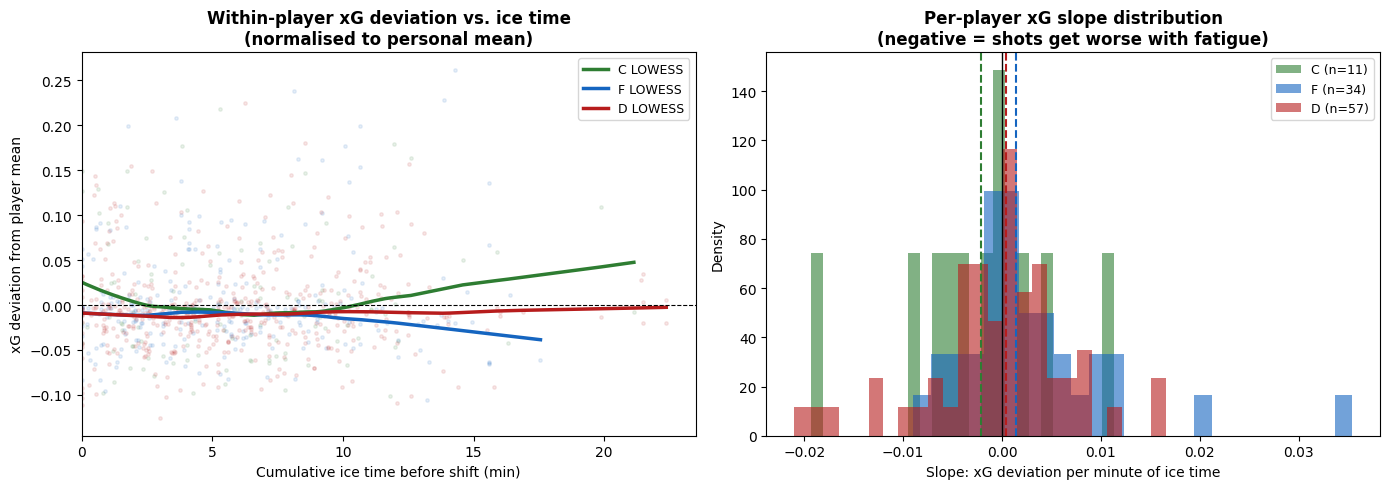

C: median slope = -0.00209  t = -1.04  p = 0.3239  (64% of players show fatigue-related decline)
F: median slope = 0.00147  t = 2.16  p = 0.0383  (38% of players show fatigue-related decline)
D: median slope = 0.00046  t = -0.42  p = 0.6790  (46% of players show fatigue-related decline)


In [22]:
wp = model_df.copy()
wp['team_player'] = wp['Team_shot'].fillna(wp.get('Team', 'UNK')) + '_' + wp['Player_Id']

# Only include players with ≥ 3 shots for reliable personal mean
player_mean_xg = wp.groupby('team_player')['xg'].mean().rename('player_mean_xg')
player_n       = wp.groupby('team_player')['xg'].count().rename('player_n_shots')
wp = wp.join(player_mean_xg, on='team_player')
wp = wp.join(player_n,       on='team_player')
wp = wp[wp['player_n_shots'] >= 3].copy()
wp['xg_dev'] = wp['xg'] - wp['player_mean_xg']

print(f"Shots from players with ≥ 3 shots: {len(wp):,}  ({wp['team_player'].nunique():,} shooters)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: xG deviation vs cumulative ice time, LOWESS
ax = axes[0]
for pos, col in POS_COLORS.items():
    s = wp[wp['position'] == pos]
    ax.scatter(s['cumulative_ice_min_before'], s['xg_dev'],
               alpha=0.10, s=6, color=col, rasterized=True)
    if len(s) >= 30:
        lw_out = lowess(s['xg_dev'].values, s['cumulative_ice_min_before'].values,
                        frac=0.5, return_sorted=True)
        ax.plot(lw_out[:, 0], lw_out[:, 1], color=col, lw=2.5, label=f'{pos} LOWESS')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Cumulative ice time before shift (min)')
ax.set_ylabel('xG deviation from player mean')
ax.set_title('Within-player xG deviation vs. ice time\n(normalised to personal mean)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(left=0)

# Panel 2: within-player OLS slope distribution across players
ax = axes[1]
slopes = []
for tp, grp in wp.groupby('team_player'):
    if len(grp) < 4:
        continue
    from scipy.stats import linregress
    sl = linregress(grp['cumulative_ice_min_before'].values, grp['xg_dev'].values).slope
    pos = grp['position'].iloc[0]
    slopes.append({'slope': sl, 'position': pos})
slopes_df = pd.DataFrame(slopes)

for pos, col in POS_COLORS.items():
    s = slopes_df[slopes_df['position'] == pos]['slope'].dropna()
    ax.hist(s, bins=25, alpha=0.6, color=col, label=f'{pos} (n={len(s)})', density=True, edgecolor='none')
    ax.axvline(s.median(), color=col, lw=1.5, ls='--')

ax.axvline(0, color='k', lw=1)
ax.set_xlabel('Slope: xG deviation per minute of ice time')
ax.set_ylabel('Density')
ax.set_title('Per-player xG slope distribution\n(negative = shots get worse with fatigue)', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_xg_within_player.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats + t-test vs 0
import scipy.stats as sps
for pos in ['C', 'F', 'D']:
    s = slopes_df[slopes_df['position'] == pos]['slope'].dropna()
    if len(s) < 2:
        print(f"{pos}: too few players (n={len(s)}) for t-test")
        continue
    t, p = sps.ttest_1samp(s, 0)
    pct_neg = (s < 0).mean()
    print(f"{pos}: median slope = {s.median():.5f}  t = {t:.2f}  p = {p:.4f}  "
          f"({100*pct_neg:.0f}% of players show fatigue-related decline)")

## Step 7 — LMM: within-player slope with player random intercepts

Full model controlling for position, rest time, score state, and period,
with player random intercepts to isolate the within-player fatigue signal.

In [ ]:

lmm_df = model_df.dropna(subset=['xg', 'cumulative_ice_min_before', 'rest_time_min']).copy()
lmm_df['team_player'] = lmm_df.get('Team_shot', lmm_df.get('Team', 'UNK')).fillna('UNK') + '_' + lmm_df['Player_Id']

lmm_formula = (
    "xg ~ cumulative_ice_min_before + rest_time_min + C(position, Treatment('D')) "
    '+ score_diff + shot_dist_ft + shot_angle_deg + shift_duration_min + C(Period_int)'
)

lmm = smf.mixedlm(lmm_formula, data=lmm_df, groups=lmm_df['team_player']).fit(reml=True)
print(lmm.summary())

player_var   = lmm.cov_re.iloc[0, 0]
residual_var = lmm.scale
icc = player_var / (player_var + residual_var)
print(f'\nICC (between-player variance fraction): {icc:.3f}')
print(f'  → {100*icc:.1f}% of xG variance is between-player (shooting skill differences)')

cum_ice_coef = lmm.params.get('cumulative_ice_min_before', float('nan'))
cum_ice_p    = lmm.pvalues.get('cumulative_ice_min_before', float('nan'))
print(f'\ncumulative_ice_min_before: coef = {cum_ice_coef:.5f},  p = {cum_ice_p:.4f}')
if cum_ice_p < 0.05:
    direction = 'DECLINE' if cum_ice_coef < 0 else 'INCREASE'
    print(f'→ Significant {direction} in xG as players accumulate ice time (controlling for position, rest, score).')
else:
    print('→ No significant relationship between cumulative ice time and xG (p ≥ 0.05).')


                   Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        xg       
No. Observations:        999            Method:                    REML     
No. Groups:              218            Scale:                     0.0010   
Min. group size:         1              Log-Likelihood:            1969.1531
Max. group size:         29             Converged:                 Yes      
Mean group size:         4.6                                                
----------------------------------------------------------------------------
                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                         0.191    0.004  47.189 0.000  0.183  0.199
C(position, Treatment('D'))[T.C]  0.009    0.003   2.628 0.009  0.002  0.016
C(position, Treatment('D'))[T.F]  0.006    0.002   2.408 0.016  0.001  0.011
C(Period_int)[T.2] 

In [24]:
# ── GEE (Binomial) on is_goal — the correct alternative to LMM on xg ─────────
# Response: actual binary outcome (is_goal), not the model-predicted xg.
# Player clustering via exchangeable correlation; gives population-average ORs
# with cluster-robust SEs — same framework as the count models in nb03.

from statsmodels.genmod.cov_struct import Exchangeable as GEE_Exchangeable

gee_bin_df = model_df.dropna(subset=[
    'is_goal', 'shot_dist_ft', 'shot_angle_deg',
    'cumulative_ice_min_before', 'rest_time_min', 'position', 'score_diff', 'shift_duration_min',
]).copy()
gee_bin_df['team_player'] = (
    gee_bin_df['Team_shot'].fillna(gee_bin_df.get('Team', 'UNK')) + '_' + gee_bin_df['Player_Id']
)
gee_bin_df = gee_bin_df.sort_values(['team_player', 'Elapsed_s']).reset_index(drop=True)

gee_bin_formula = (
    'is_goal ~ shot_dist_ft + shot_angle_deg '
    '+ cumulative_ice_min_before + rest_time_min '
    "+ C(position, Treatment('D')) + score_diff + C(Period_int) + shift_duration_min"
)

gee_bin = smf.gee(
    gee_bin_formula,
    groups='team_player',
    data=gee_bin_df,
    family=sm.families.Binomial(),
    cov_struct=GEE_Exchangeable(),
).fit()

print(gee_bin.summary())

within_corr_bin = gee_bin.cov_struct.dep_params
print(f'\nEstimated within-player correlation (α) : {within_corr_bin:.4f}')

# Odds ratios
fatigue_terms = [
    'cumulative_ice_min_before', 'rest_time_min',
    "C(position, Treatment('D'))[T.C]", "C(position, Treatment('D'))[T.F]",
    'score_diff', 'shift_duration_min',
]
params = gee_bin.params
conf   = gee_bin.conf_int()
pvals  = gee_bin.pvalues
or_rows = []
for t in fatigue_terms:
    if t in params.index:
        or_rows.append({
            'Predictor': t,
            'OR'       : np.exp(params[t]),
            'CI_lo'    : np.exp(conf.loc[t, 0]),
            'CI_hi'    : np.exp(conf.loc[t, 1]),
            'p'        : pvals[t],
        })
or_df = pd.DataFrame(or_rows).set_index('Predictor')
or_df['sig'] = or_df['p'].apply(lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '')))
print('\nOdds Ratios — GEE Binomial (is_goal):')
print(or_df.round(4).to_string())

cum_ice_p = pvals.get('cumulative_ice_min_before', float('nan'))
cum_ice_or = np.exp(params.get('cumulative_ice_min_before', float('nan')))
print(f'\ncumulative_ice_min_before: OR = {cum_ice_or:.4f},  p = {cum_ice_p:.4f}')
if cum_ice_p < 0.05:
    direction = 'DECLINE' if cum_ice_or < 1 else 'INCREASE'
    print(f'→ Significant {direction} in goal probability with cumulative ice time.')
else:
    print('→ No significant relationship between cumulative ice time and goal probability (p ≥ 0.05).')


                               GEE Regression Results                              
Dep. Variable:                     is_goal   No. Observations:                  999
Model:                                 GEE   No. clusters:                      218
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                  29
Family:                           Binomial   Mean cluster size:                 4.6
Dependence structure:         Exchangeable   Num. iterations:                    10
Date:                     Sun, 15 Mar 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         08:59:49
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            1.533

## Step 8 — Does fatigue change shot *location*, not just shot *outcome*?

The xG model already accounts for distance and angle. So if fatigued players take shots
from farther out or from worse angles, the model captures that — but the *cause* is
fatigue, not random shot selection noise.

This section asks the upstream question: **does cumulative ice time predict where shots
are taken from?** If yes, fatigue is changing the shot-taking behavior (location, type)
rather than a player's ability to convert from a fixed location.

This also explains why the augmented logistic regression may show a weak direct fatigue
effect: both the shooter *and* the defenders are fatiguing, keeping relative conversion
rates stable, while the absolute shot locations drift.


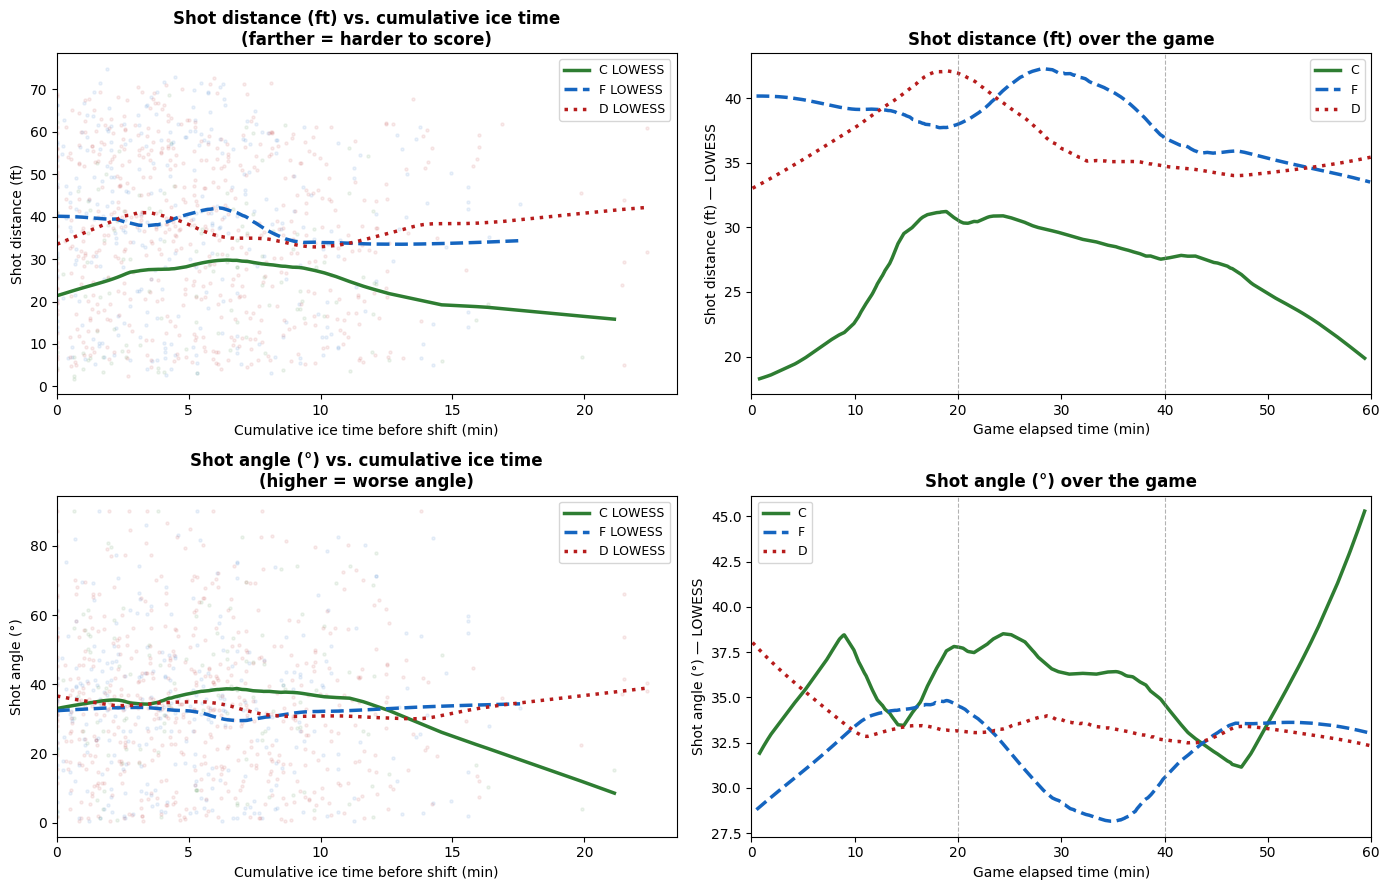

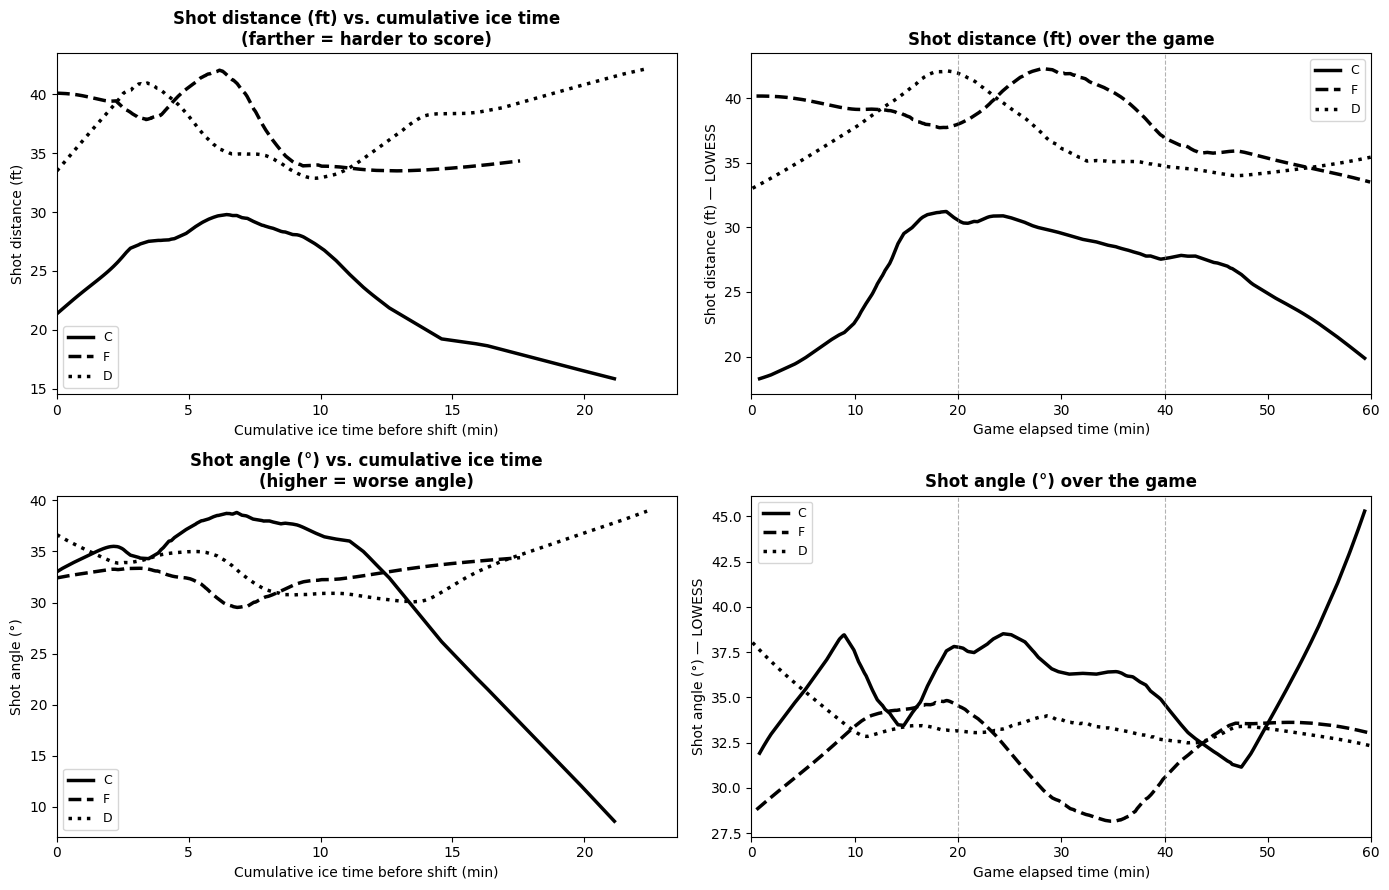

In [ ]:

# ── LOWESS: shot distance and angle vs cumulative ice time ───────────────────
metrics = [
    ('shot_dist_ft',   'Shot distance (ft)',   'farther = harder to score'),
    ('shot_angle_deg', 'Shot angle (°)',        'higher = worse angle'),
]

# Shared plot function — parameterised for color vs B&W
POS_STYLES = {
    'C': {'ls': '-',  'marker': 'o'},
    'F': {'ls': '--', 'marker': 's'},
    'D': {'ls': ':',  'marker': '^'},
}

def draw_location_grid(fig, axes, use_color):
    for row_i, (metric, ylabel, note) in enumerate(metrics):
        ax = axes[row_i]
        for pos, style in POS_STYLES.items():
            col = POS_COLORS[pos] if use_color else 'black'
            s = shot_shifts[shot_shifts['position'] == pos].dropna(
                    subset=[metric, 'cumulative_ice_min_before'])
            if use_color:
                ax.scatter(s['cumulative_ice_min_before'], s[metric],
                           alpha=0.08, s=5, color=col, rasterized=True)
            if len(s) >= 30:
                lw_out = lowess(s[metric].values, s['cumulative_ice_min_before'].values,
                                frac=0.5, return_sorted=True)
                ax.plot(lw_out[:, 0], lw_out[:, 1],
                        color=col, lw=2.5, ls=style['ls'],
                        label=f'{pos} LOWESS')
        ax.set_xlabel('Cumulative ice time before shift (min)')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel} vs. cumulative ice time\n({note})', fontweight='bold')
        ax.legend(fontsize=9)
        ax.set_xlim(left=0)

# ── Figure 1: colour version ──────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))
draw_location_grid(fig1, axes1, use_color=True)
fig1.tight_layout()
fig1.savefig(OUTPUT_DIR / '05_shot_location_vs_fatigue.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: black-and-white version (line pattern only) ────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
draw_location_grid(fig2, axes2, use_color=False)
# Add line-style legend entries
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='black', lw=2.5, ls=style['ls'], label=pos)
    for pos, style in POS_STYLES.items()
]
for ax in axes2:
    ax.legend(handles=legend_handles, fontsize=9)
fig2.tight_layout()
fig2.savefig(OUTPUT_DIR / '05_shot_location_vs_fatigue_bw.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

# ── LMM: does cumulative ice time predict shot distance / angle? ─────────────
# Player random intercepts because shooters have different baseline tendencies
# (some players always shoot from the slot; some always from the perimeter).

loc_df = shot_shifts.dropna(subset=[
    'shot_dist_ft', 'shot_angle_deg', 'cumulative_ice_min_before',
    'rest_time_min', 'position', 'score_diff', 'shift_duration_min',
]).copy()
loc_df['team_player'] = loc_df.get('Team_shot', loc_df.get('Team', 'UNK')).fillna('UNK') + '_' + loc_df['Player_Id']

loc_formula = (
    "{y} ~ cumulative_ice_min_before + rest_time_min "
    "+ C(position, Treatment('D')) + score_diff + shift_duration_min + C(Period_int)"
)

print('=' * 65)
for outcome, unit in [('shot_dist_ft', 'ft'), ('shot_angle_deg', '°')]:
    lmm_loc = smf.mixedlm(
        loc_formula.format(y=outcome),
        data=loc_df,
        groups=loc_df['team_player'],
    ).fit(reml=True)

    coef = lmm_loc.params.get('cumulative_ice_min_before', float('nan'))
    p    = lmm_loc.pvalues.get('cumulative_ice_min_before', float('nan'))
    ci   = lmm_loc.conf_int().loc['cumulative_ice_min_before'] if 'cumulative_ice_min_before' in lmm_loc.conf_int().index else [float('nan'), float('nan')]

    pv   = lmm_loc.cov_re.iloc[0, 0]
    rv   = lmm_loc.scale
    icc  = pv / (pv + rv)

    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    print(f'\n{outcome}')
    print(f'  cumulative_ice_min_before: coef = {coef:+.4f} {unit}/min  '
          f'95% CI [{ci[0]:+.4f}, {ci[1]:+.4f}]  p = {p:.4f}  {sig}')
    print(f'  ICC (player random effect): {icc:.3f}')
    if p < 0.05:
        direction = 'FARTHER' if (outcome == 'shot_dist_ft' and coef > 0) else \
                    'CLOSER'  if (outcome == 'shot_dist_ft' and coef < 0) else \
                    'WIDER ANGLE' if coef > 0 else 'TIGHTER ANGLE'
        print(f'  → Significant: fatigued players shoot from {direction}')
    else:
        print(f'  → Not significant: shot {outcome.split("_")[1]} unchanged with fatigue')

print()
print('=' * 65)
print('\nInterpretation:')
print('If distance ↑ with fatigue → tired players are pushed to worse shot locations.')
print('If angle ↑ with fatigue    → tired players are forced to wider/harder angles.')
print('Either finding means fatigue is already priced into xG via location features.')



shot_dist_ft
  cumulative_ice_min_before: coef = -0.0295 ft/min  95% CI [-0.5667, +0.5078]  p = 0.9144  n.s.
  ICC (player random effect): 0.302
  → Not significant: shot dist unchanged with fatigue

shot_angle_deg
  cumulative_ice_min_before: coef = -0.3640 °/min  95% CI [-0.9742, +0.2462]  p = 0.2423  n.s.
  ICC (player random effect): 0.091
  → Not significant: shot angle unchanged with fatigue


Interpretation:
If distance ↑ with fatigue → tired players are pushed to worse shot locations.
If angle ↑ with fatigue    → tired players are forced to wider/harder angles.
Either finding means fatigue is already priced into xG via location features.


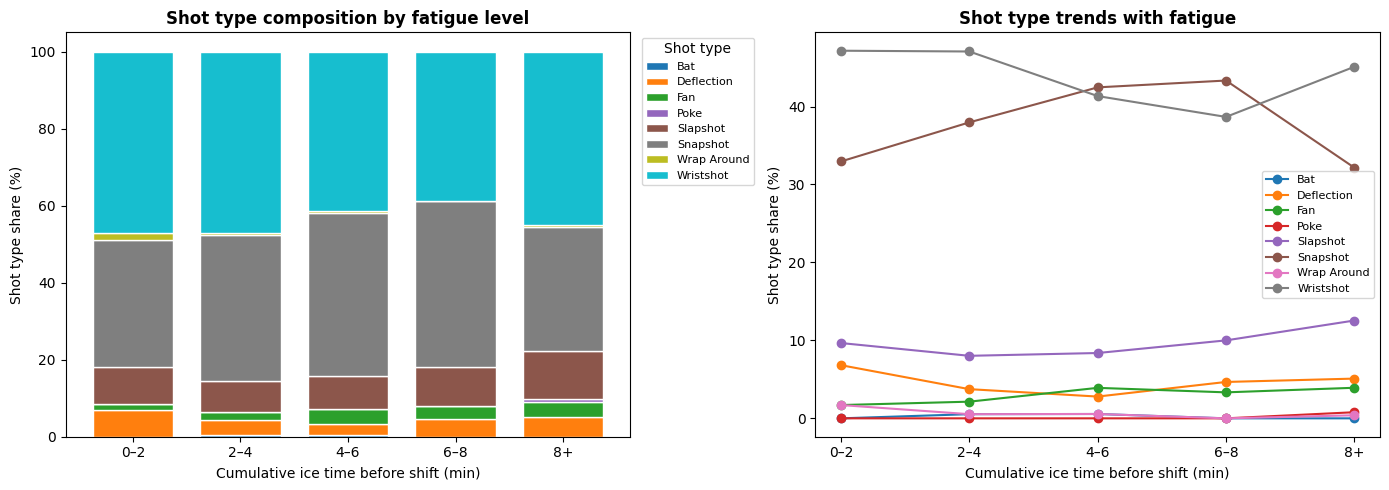


Shot type percentages by fatigue bin:
shot_type    Bat  Deflection  Fan  Poke  Slapshot  Snapshot  Wrap Around  Wristshot
cum_ice_bin                                                                        
0–2          0.0         6.8  1.7   0.0       9.7      33.0          1.7       47.2
2–4          0.5         3.7  2.1   0.0       8.0      38.0          0.5       47.1
4–6          0.6         2.8  3.9   0.0       8.4      42.5          0.6       41.3
6–8          0.0         4.7  3.3   0.0      10.0      43.3          0.0       38.7
8+           0.0         5.1  3.9   0.8      12.5      32.2          0.4       45.1


In [27]:
# ── Shot type composition vs. fatigue ────────────────────────────────────────
# Does the mix of shot types (Wrist, Slap, Snap, Tip-In, Backhand) shift
# as players fatigue? Slap shots require more wind-up effort; wrist/snap are
# quicker. A shift toward easier-to-execute shot types would be a fatigue signal.

type_df = shot_shifts.dropna(subset=['shot_type', 'cumulative_ice_min_before']).copy()
type_df['cum_ice_bin'] = pd.cut(
    type_df['cumulative_ice_min_before'],
    bins=[0, 2, 4, 6, 8, 100],
    labels=['0–2', '2–4', '4–6', '6–8', '8+'],
)

# Proportion of each shot type per cumulative ice bin
type_counts = (
    type_df.groupby(['cum_ice_bin', 'shot_type'], observed=True)
    .size()
    .unstack(fill_value=0)
)
type_pct = type_counts.div(type_counts.sum(axis=1), axis=0) * 100

# Keep only types with > 2% share overall to avoid clutter
common_types = (type_pct.mean() > 2).index
type_pct = type_pct[common_types]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar
ax = axes[0]
type_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='white', width=0.75)
ax.set_xlabel('Cumulative ice time before shift (min)')
ax.set_ylabel('Shot type share (%)')
ax.set_title('Shot type composition by fatigue level', fontweight='bold')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Shot type', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

# Line chart: individual type trends
ax = axes[1]
x_pos = range(len(type_pct))
for stype in common_types:
    ax.plot(x_pos, type_pct[stype].values, marker='o', label=stype)
ax.set_xticks(list(x_pos))
ax.set_xticklabels(type_pct.index.astype(str))
ax.set_xlabel('Cumulative ice time before shift (min)')
ax.set_ylabel('Shot type share (%)')
ax.set_title('Shot type trends with fatigue', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_shot_type_vs_fatigue.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nShot type percentages by fatigue bin:')
print(type_pct.round(1).to_string())


## Step 9 — Fanned shots as execution errors

A fanned shot (Detail_1 == 'Fan') is a direct execution failure — the player swung
and missed or badly mishit the puck. Unlike shot distance or angle (which reflect
positioning), a fan is an unambiguous skill error. If fatigue degrades fine motor
control, we'd expect the fan rate to rise with cumulative ice time.

**Model**: logistic regression with `is_fan` as the binary outcome across all shot
attempts (excluding blocked shots, which never reached the release point). Controls
for position and rest time so we isolate the within-player fatigue effect.


In [28]:
# ── Build fan-shot DataFrame ──────────────────────────────────────────────────
# All unblocked shot attempts (Detail_2 != 'Blocked') are the denominator.
# Blocked shots are excluded because the player released the puck — no execution error.
fan_base = shot_shifts[shot_shifts.get('Detail_2', pd.Series('', index=shot_shifts.index)).ne('Blocked')].copy()
fan_base['is_fan'] = (fan_base['shot_type'] == 'Fan').astype(int)

n_total_shots = len(fan_base)
n_fans        = fan_base['is_fan'].sum()
print(f"Unblocked shot attempts : {n_total_shots:,}")
print(f"Fanned shots            : {n_fans}  ({100*n_fans/n_total_shots:.2f}% fan rate)")
print()
print("Fan rate by cumulative ice bin:")
fan_base['cum_ice_bin'] = pd.cut(
    fan_base['cumulative_ice_min_before'],
    bins=[0, 2, 4, 6, 8, 100],
    labels=['0–2', '2–4', '4–6', '6–8', '8+'],
)
fan_rate_by_bin = fan_base.groupby('cum_ice_bin', observed=True).agg(
    attempts=('is_fan', 'count'),
    fans=('is_fan', 'sum'),
).assign(fan_pct=lambda d: 100 * d['fans'] / d['attempts'])
print(fan_rate_by_bin.to_string())


Unblocked shot attempts : 744
Fanned shots            : 29  (3.90% fan rate)

Fan rate by cumulative ice bin:
             attempts  fans   fan_pct
cum_ice_bin                          
0–2               125     3  2.400000
2–4               142     4  2.816901
4–6               132     7  5.303030
6–8               109     5  4.587156
8+                196     9  4.591837


In [ ]:

# ── Logistic regression: is_fan ~ cumulative_ice_min_before + controls ────────
import scipy.stats as sps

fan_df = fan_base.dropna(subset=[
    'is_fan', 'cumulative_ice_min_before', 'rest_time_min', 'position', 'score_diff',
    'shift_duration_min',
]).copy()
fan_df['team_player'] = fan_df.get('Team_shot', fan_df.get('Team', 'UNK')).fillna('UNK') + '_' + fan_df['Player_Id']

fan_formula = (
    'is_fan ~ cumulative_ice_min_before + rest_time_min '
    "+ C(position, Treatment('D')) + score_diff + shift_duration_min + C(Period_int)"
)
logit_fan = smf.logit(fan_formula, data=fan_df).fit(disp=False, method='bfgs')
print(logit_fan.summary2())

# Key coefficient: cumulative ice time
coef = logit_fan.params.get('cumulative_ice_min_before', float('nan'))
p    = logit_fan.pvalues.get('cumulative_ice_min_before', float('nan'))
ci   = logit_fan.conf_int().loc['cumulative_ice_min_before']
or_  = np.exp(coef)
or_ci = np.exp(ci)

print(f"\ncumulative_ice_min_before:")
print(f"  OR = {or_:.3f}  (95% CI {or_ci[0]:.3f}–{or_ci[1]:.3f})  p = {p:.4f}")
sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
print(f"  {sig}")
if p < 0.05:
    direction = 'INCREASE' if coef > 0 else 'DECREASE'
    print(f"  → Fan rate significantly {direction}s with cumulative ice time.")
    if coef > 0:
        print(f"  → Each additional minute of ice time multiplies fan odds by {or_:.3f}x.")
else:
    print("  → No significant relationship between cumulative ice time and fan rate.")


                                 Results: Logit
Model:                     Logit                 Pseudo R-squared:      0.037   
Dependent Variable:        is_fan                AIC:                   251.9412
Date:                      2026-03-15 08:59      BIC:                   288.8375
No. Observations:          744                   Log-Likelihood:        -117.97 
Df Model:                  7                     LL-Null:               -122.52 
Df Residuals:              736                   LLR p-value:           0.24495 
Converged:                 0.0000                Scale:                 1.0000  
Method:                    MLE                                                  
--------------------------------------------------------------------------------
                                  Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
--------------------------------------------------------------------------------
Intercept                        -3.5768   0.5244 -6.8211 0.0

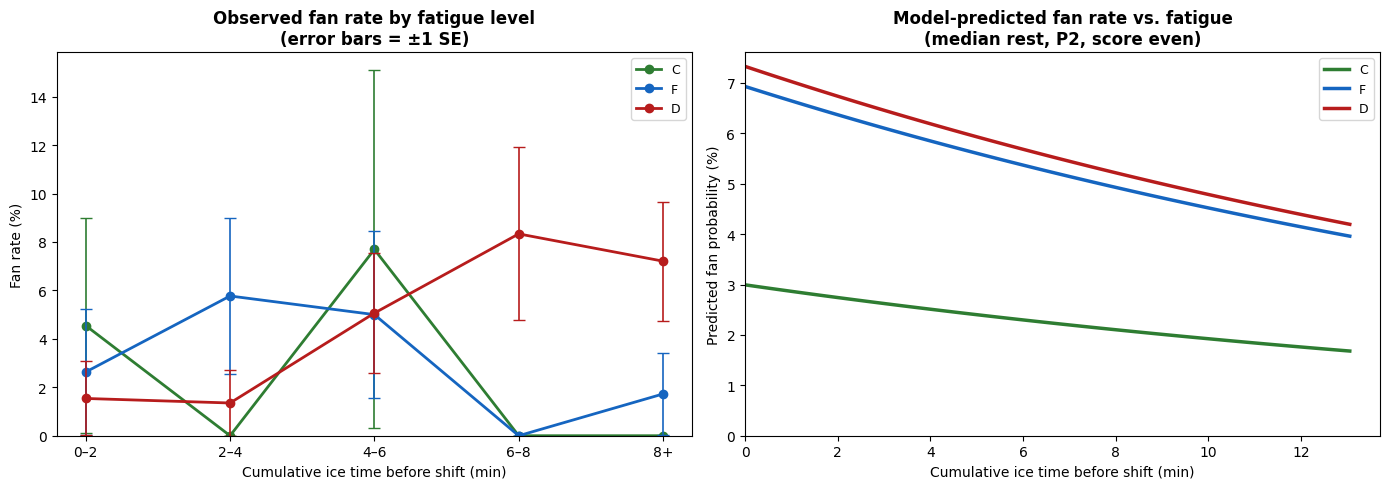


Note: only 29 fanned shots in dataset — interpret with caution.
The logistic regression is likely underpowered; wide CIs are expected.


In [30]:
# ── Visual: fan rate by fatigue bin + predicted probability curve ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: observed fan rate by cumulative ice bin, by position
ax = axes[0]
for pos, col in POS_COLORS.items():
    s = fan_base[fan_base['position'] == pos]
    s_bin = s.groupby('cum_ice_bin', observed=True).agg(
        attempts=('is_fan', 'count'),
        fans=('is_fan', 'sum'),
    ).assign(fan_pct=lambda d: 100 * d['fans'] / d['attempts'])
    x_pos = range(len(s_bin))
    ax.plot(list(x_pos), s_bin['fan_pct'].values, marker='o', color=col, lw=2, label=pos)
    # Error bars: Wilson CI
    for xi, (_, row) in zip(x_pos, s_bin.iterrows()):
        n, k = int(row['attempts']), int(row['fans'])
        if n > 0:
            p_hat = k / n
            se = np.sqrt(p_hat * (1 - p_hat) / n)
            ax.errorbar(xi, row['fan_pct'], yerr=se * 100, fmt='none', color=col, capsize=4, lw=1.2)

ax.set_xticks(range(len(fan_rate_by_bin)))
ax.set_xticklabels(fan_rate_by_bin.index.astype(str))
ax.set_xlabel('Cumulative ice time before shift (min)')
ax.set_ylabel('Fan rate (%)')
ax.set_title('Observed fan rate by fatigue level\n(error bars = ±1 SE)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)

# Panel 2: model-predicted fan probability vs cumulative ice time
ax = axes[1]
ice_range = np.linspace(0, fan_df['cumulative_ice_min_before'].quantile(0.95), 100)
for pos, col in POS_COLORS.items():
    pred_df = pd.DataFrame({
        'cumulative_ice_min_before': ice_range,
        'rest_time_min'            : fan_df['rest_time_min'].median(),
        'position'                 : pos,
        'score_diff'               : 0,
        'Period_int'               : 2,
    })
    pred_df['Period_int'] = pred_df['Period_int'].astype(int)
    probs = logit_fan.predict(pred_df)
    ax.plot(ice_range, probs * 100, color=col, lw=2.5, label=pos)

ax.set_xlabel('Cumulative ice time before shift (min)')
ax.set_ylabel('Predicted fan probability (%)')
ax.set_title('Model-predicted fan rate vs. fatigue\n(median rest, P2, score even)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_fan_rate_vs_fatigue.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNote: only {n_fans} fanned shots in dataset — interpret with caution.")
print("The logistic regression is likely underpowered; wide CIs are expected.")